# Нарративы престижности и доступности высшего образования в московских вузах (на примере публикаций в новостных сообществах ВКонтакте за 2020-2025 гг.)

## Логика ноутбука

Данный ноутбук отражает реализацию базового эмпирического этапа исследования: от подготовки корпуса публикаций и комментариев до первичной проверки связи между медианарративами и пользовательской вовлеченностью.

Мы фокусируемся на двух типах медианарративов: нарратив престижности высшего образования и нарратив его социальной доступности.  
Престижность операционализируется через маркеры достижений, рейтингов, научных прорывов, международных связей, экспертности и карьеры.  
Доступность операционализируется через маркеры поступления, бюджетных мест, стоимости обучения, квоты, стипендии, льготы, консультации,поддержку и инфраструктуру.

Ноутбук решает следующие задачи:  
1. Загружает корпус публикаций университетских сообществ ВКонтакте, а также слой публикаций с комментариями.
2. Создает новые признаки: календарные, текстовые и поведенческие.
3. Очищает тексты и выделяет словарные маркеры, характеризующие престижность и доступность.
4. Классифицирует публикации на 4 нарративных категории: престижность, доступность, смешанная и другое.
5. Отделяет содержательные комментарии от механических, ритуальных и конкурсных реакций.
6. Проводит сравнение нарративных классов по лайкам, репостам, комментариям, содержательным комментариям и вопросительным комментариям.
7. Выделяет тематическую структуру корпуса с помощью LDA.
8. Анализирует контексты доступности через частотные n-граммы и KWIC (key word in context).
9. Строит baseline-модели, чтобы проверить, насколько текстовые и метаданные признаки позволяют классификационно различать публикации с высоким и низким содержательным откликом.

## Импорт библиотек и настройка параметров отображения элементов

In [1]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from IPython.display import display, Markdown
from collections import Counter
import emoji
from tqdm import tqdm

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.float_format', lambda x:f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
sns.set_palette('pastel')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'Times New Roman'

## Загрузка данных и создание признаков

In [2]:
posts = pd.read_csv('/Users/ekaterinamalkova/Desktop/vkr_analysis/data/data_unis.csv')
comms = pd.read_csv('/Users/ekaterinamalkova/Desktop/vkr_analysis/data/data_with_comments.csv')
comms = comms.drop(columns=['Unnamed: 0'])

In [3]:
# создаем признаки года, месяца, квартала, дня недели и времени года
# создаем признаки вовлеченности
for df in [posts, comms]:
    df['date'] = pd.to_datetime(df['date'])
    
    for col in ['likes', 'comments_count', 'reposts', 'views']:
        df[col] = pd.to_numeric(df[col])

    df['likes_p1000_views'] = df['likes'] / df['views'] * 1000
    df['comments_p1000_views'] = df['comments_count'] / df['views'] * 1000
    df['reposts_p1000_views'] = df['reposts'] / df['views'] * 1000
    df['log_views'] = np.log1p(df['views'])
    df['log_likes'] = np.log1p(df['likes'])
    df['log_comments_count'] = np.log1p(df['comments_count'])
    df['log_reposts'] = np.log1p(df['reposts'])
        

    df['year'] = df['date'].dt.year.astype('Int64')
    df['month'] = df['date'].dt.month.astype('Int64')
    df['quarter'] = df['date'].dt.quarter
    df['weekday'] = df['date'].dt.day_name()
    df['season'] = np.select([df['month'].isin([12, 1, 2]),
                              df['month'].isin([3, 4, 5]),
                              df['month'].isin([6, 7, 8]),
                              df['month'].isin([9, 10, 11])],
                             ['winter', 'spring', 'summer', 'autumn'], default='unknown')

## Далее поработаем над текстом: текстами публикаций и комментариев

### Вспомогательные функции для текстовых представлений

In [4]:
display(comms.sort_values('comments_count', ascending=False).head(30))
display(Markdown(f'Видим, что публикации с числом комментариев более, чем 2500 – розыгрыши и конкурсы, поэтому установим ограничения'))

,post_id,date,text,likes,comments_count,reposts,views,source_nickname,group_id,post_link,comments,likes_p1000_views,comments_p1000_views,reposts_p1000_views,log_views,log_likes,log_comments_count,log_reposts,year,month,quarter,weekday,season
27665,54782,2021-01-29,"В нашей галактике более 100 миллиардов звезд и более 800 миллиардов планет. Одна из них — планета РУДН, на которой тоже есть свои звезды — студент...",208,61061,56,14087,rudn.csv,"-1,711.00",https://vk.com/club1711?w=wall-1711_54782,⭐ | ⭐️ | 🌟 | 💫 | 🌍🌎🌏 | ⭐️⭐️⭐️ | 💫 | 🌟 | ⭐️ | 💫 | ⭐️ | 🌍 | 🌎 | 🌏 | 🌟 | 💫 | 🤩🤩🤩 | штош | погнали | 🎆 | 🌠 | ✨ | 🌟 | 🌟 | 💫 | 💥 | 💫 | 💫💫💫 | 💫 | 🌟 | 💫 |...,14.77,"4,334.56",3.98,9.55,5.34,11.02,4.04,2021,1,1,Friday,winter
2323,105478,2023-09-29,Проголодались? 👀 \n \nНачинаем великую маёвскую битву за набор горячей пиццы от наших друзей — проекта [https://vk.com/znanie_igra|«Знание.Игра»] ...,757,42464,74,11849,mai.csv,"-50,409,684.00",https://vk.com/club50409684?w=wall-50409684_105478,М6О-102БВ-23 | М6О-102БВ-23 | М6О-102БВ-23 | М4О-104С-23 | М6О-102БВ-23 | М6О-102БВ-23 | М6О-102БВ-23 | М6О-102БВ-23 | М6О-102БВ-23 | М6О-102БВ-23...,63.89,"3,583.76",6.25,9.38,6.63,10.66,4.32,2023,9,3,Friday,autumn
37680,19246,2022-04-13,"В преддверии Дня губкинца ищем нефть!\n\nНа нашей карте нанесены 92 нефтяных месторождения, из которых можно добыть ценные призы.\n\nПравила поиск...",526,36964,494,65381,gubkin.csv,"-71,938,736.00",https://vk.com/club71938736?w=wall-71938736_19246,A1 | P10 | R15 | I5 | AA10 | А10 | W10 | C3 | AI28 | X15 | X15 | S22 | H12 | AT53 | S18 | E47 | Z4 | B12 | E15 | L8 | F7 | G32 | B12 | G92 | N26 |...,8.05,565.36,7.56,11.09,6.27,10.52,6.20,2022,4,2,Wednesday,spring
14000,86518,2023-10-30,"🍕 Где самая вкусная пицца? Правильно, в РТУ МИРЭА! \n \nВ честь открытия нового пункта питания, расположенного под главной лестницей в корпусе на ...",196,32721,130,21095,mirea.csv,"-1,388.00",https://vk.com/club1388?w=wall-1388_86518,ЭСБО-01-20 | УИБО-02-22 | Икбо-61-23 | УИБО-02-22 | Уибо-02-22 | УИБО-02-22 | УИБО-02-22 | Икбо-61-23 | УИБО-02-22 | ИКБО-61-23 | УИБО-02-22 | ИКБ...,9.29,"1,551.13",6.16,9.96,5.28,10.40,4.88,2023,10,4,Monday,autumn
36591,98419,2025-04-06,"В День геолога начинаем геологоразведочные работы!\n\nНа нашей карте нанесены 35 нефтегазовых месторождений, из которых можно добыть ценные призы ...",345,27651,142,24151,gubkin.csv,"-71,938,736.00",https://vk.com/club71938736?w=wall-71938736_98419,T13 | CB3 | BI65 | Y23 | G9 | Y23 | AO43 | CD60 | Q5 | Y23 | BQ28 | AQ34 | Q5 | F28 | AF46 | А1 | BE7 | AS25 | X33 | BY16 | G7 | V8 | AF46 | X33 |...,14.29,"1,144.92",5.88,10.09,5.85,10.23,4.96,2025,4,2,Sunday,spring
37438,59985,2023-04-17,"В День Губкинца начинаем поисково-разведочные работы!\n\nНа нашей карте нанесены 35 нефтегазовых месторождений, из которых можно добыть ценные при...",419,27227,244,47941,gubkin.csv,"-71,938,736.00",https://vk.com/club71938736?w=wall-71938736_59985,AQ17 | W7 | J17 | O30 | S9 | AB32 | G4 | BV81 | AX17 | D1 | AB32 | AB32 | AC28 | Y18 | A7 | R47 | W7 | B22 | CL1 | G23 | CL1 | AC9 | A6 | AS47 | I...,8.74,567.93,5.09,10.78,6.04,10.21,5.50,2023,4,2,Monday,spring
97538,128424,2023-09-07,"Привет, обещали розыгрыш с 10 призами? Вот он!\n\nБесплатные поездки на городском велосипеде? Легко! \n \nДля этого есть Велобайк - городской вело...",51,25106,12,7078,reu.csv,"-1,177.00",https://vk.com/club1177?w=wall-1177_128424,Все участвуем!!! | привет всем! а что тут происходит? | привет! а что происходит? | привет! а что происходит? | привет! а что происходит? | привет...,7.21,"3,547.05",1.70,8.86,3.95,10.13,2.56,2023,9,3,Thursday,autumn
97550,107748,2023-09-01,Дарим худи РЭУ. РФ самому активному подписчику!\n\nПравила участия просты - больше стикеров в комментариях под этой записью - больше шанс выиграть...,306,20524,36,365214,reu.csv,"-1,177.00",https://vk.com/club1177?w=wall-1177_107748,"👋 | 🥳 | 🎁 | ❤️ | 🙌 | Топчик | Классный розыгрыш 🔥 | Моё сообщение = 10 000 стикероу с котиком | РЭУ 👍 | 👍 | 👍 | Зачем вам считать ст

Видим, что публикации с числом комментариев более, чем 2500 – розыгрыши и конкурсы, поэтому установим ограничения

In [5]:
# разделяет комментарии по границе ' | '
def split_comms(text, max_comments=2500):
    if not isinstance(text, str) or not text.strip():
        return [], 0
    parts = [part.strip() for part in re.split(r'\s+\|\s+', text) if part.strip()]
    if not parts and text.strip():
        parts = [text.strip()]
    return parts[:max_comments], len(parts)

Стоп-слова и корпусный шум  

  Для анализа помимо стандартных стоп-слов на русском языке используются еще и кастомные, отражающие специфику текстов и элементов, часто повторяющихся сочетаний и службеных слов.  
  Такие слова могут быть очень частотными, но при этом совсем не помогать различать нарративы и содержательные темы.Некоторые элементы и ссылки могут отражать источник публикации, но не ее смысл, поэтому они исключаются из токенизации и тематического моделирования.

In [6]:
from nltk.corpus import stopwords

custom_stopwords = {'vk', 'cc', 'club', 'id', 'com', 'http', 'https', 'ru', 'www',
                   'подробнее', 'ссылка', 'материал', 'ссылке', 'ссылку', 'ссылкой', 'материале',
                   'материалом', 'новость', 'новостью', 'московский', 'университет', 'университета',
                   'вуз', 'вуза', 'вузу', 'ниу', 'мгу', 'вшэ', 'ранхигс', 'мисис', 'рэу', 'подробнее', 'новостная',
                   'мгту', 'рггу', 'мгимо', 'вышка', 'мирэа','url', 'года', 'году', 'год', 'лет', 'день',
                   'дней', 'этом', 'этот', 'также', 'это', 'для', 'что', 'как', 'или', 'можно', 'только',
                   'россии', 'российской', 'российский', 'федерации', 'федерация', 'рф', 'участие',
                   'участия', 'принять', 'приняли', 'рамках', 'регистрация', 'университет', 'университета',
                   'студент', 'студентов', 'студенты'}

ru_stopwords = custom_stopwords | set(stopwords.words('russian'))

In [7]:
# производит базовую нормализацию текста: удаляет все лишнее, приводит ссылки и упоминания к красивому виду
def normalise_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'https?://\S+|www\.\S+|vk\.cc/\S+', ' URL ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'[@#][\wа-яА-ЯёЁ_]+;', ' ', text)
    text = text.lower().replace('ё', 'е')
    text = re.sub(r'[^а-яa-z\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# токенизация с очисткой мусора и стопслов
def tokenise_clean(text):
    return [token for token in re.findall(r'[а-яa-z]{3,}', text.lower().replace('ё','е')) if token not in ru_stopwords]

Операционализация нарративов  

  Нарративы престижности и доступности благодаря словарей с регулярными выражениями переводятся в измеримые признаки.  
  Нарратив престижности операционализируется через маркеры элитности, достижений, рейтингов, научных прорывов, международных связей, экспертности и карьеры.  
Нарратив доступности включает финансовые, процедурные, информационные и инфраструктурные маркеры: поступление, бюджетные места, стоимость обучения, квоты, стипендии, льготы, консультации,поддержка и инфраструктура.  

  Благодаря такому подходу мы можем масштабировать анализ на большой корпус публикаций.

In [8]:
# набор регулярных выражений для паттернов престижности и доступности
prestige_patterns = {'elite_selective': r'\b(элитн\w*|селективн\w*|отборн\w*|лучши\w*|топ\w*|лидер\w*|конкурсн\w*|ведущ\w*|престиж\w*|рейтинг\w*|перв\w*\s+мест\w*)\b',
                    'achievement': r'\b(побед\w*|приз\w*|лауреат\w*|награ\w*|преми\w*|медал\w*|финалист\w*|чемпион\w*|успех\w*|успеш\w*|достижен\w*|выигр\w*|триумф\w*|прорыв\w*)\b',
                    'science': r'\b(научн\w*|исследова\w*|публикац\w*|цитируем\w*|статья\w*|статью\w*|лаборатор\w*|эксперт\w*|инновац\w*|разработк\w*|технолог\w*|исследовательск\w+\s+грант|грант\s+рнф\w*|рффи|госзадан\w*|патент\w*)\b',
                    'international_career': r'\b(международн\w*|глобаль\w*|партнер\w*|работодател\w*|карьер\w*|специалист\w*|аккредитац\w*|выпускник\w*)\b'} 

access_patterns = {'financial_access': r'\b(бюджет\w*|платн\w*|стоимост\w*|оплат\w*|скидк\w*|стипен\w*|образовательн.{0,20}грант\w*|грант.{0,30}поддержк\w*|льгот\w*|квот\w*|рассроч\w*|кредит\w*|субсид\w*|материальн\w+\s+помощ\w*|социальн\w+\s+лифт\w*)\b',
                    'procedural_access': r'\b(поступлен\w*|при[ёе]м\w*|егэ\w*|балл\w*|документ\w*|зачислен\w*|конкурсн\w+\s+списк\w*|целев\w*|вступительн\w*|дедлайн\w*|заявлен\w*|договор\w*)\b',
                    'informational_access': r'\b(вебинар\w*|консультац\w*|инструкц\w*|навигатор\w*|гайд\w*|вопрос\w*|ответ\w*|регистрац\w*|день\s+открытых\s+двер\w*|при[ёе]мн\w+\s+комисс\w*|дод\w*)\b',
                    'infrastructure_support': r'\b(общежити\w*|кампус\w*|инклюзи\w*|доступн\w+\s+сред\w*|поддержк\w*|психолог\w*|тьютор\w*|куратор\w*|наставни\w*|адаптац\w*|помощ\w+\s+студент\w*)\b'}

def count_regex(series, pattern):
    return series.fillna('').str.count(pattern)

# набор регулярных выражений для определения сентимента текста
positive_pattern = re.compile(
    r'\b(успех\w*|лучш\w*|побед\w*|рад\w*|достижен\w*|горд\w*|поздрав\w*|важн\w*|'
    r'благодар\w*|интересн\w*|нов\w*|возможност\w*|вдохнов\w*|'
    r'уникальн\w*|прорыв\w*|поддерж\w*|полезн\w*|сильн\w*|инноваци\w*|успех\w*|успешн\w*)\b',
    flags=re.IGNORECASE,)

negative_pattern = re.compile(
    r'\b(проблем\w*|трудност\w*|сложн\w*|риск\w*|препятств\w*|барьер\w*|дорог\w*|'
    r'недоступн\w*|жалоб\w*|отказ\w*|конфликт\w*|стресс\w*|задерж\w*|ошибк\w*|трево\w*|'
    r'нехват\w*|дефиц\w*|скандал\w*|несправедлив\w*|неравн\w*|коррупц\w*|огранич\w*)\b',
    flags=re.IGNORECASE,)

# нормализует текст, подсчитывает + и 0 паттерны и вычисляет сентимент (с нормализацией на длину текста)
def sentiment_for_text(text):
    if not text:
        return 0.0
    clean = normalise_text(text)
    tokens = max(1, len(tokenise_clean(clean)))
    pos = len(positive_pattern.findall(clean))
    neg = len(negative_pattern.findall(clean))
    return (pos - neg) / math.sqrt(tokens)

Почему анализируются содержательные комментарии  

  В исследовании важны не просто комментарии как количественный показатель, отражающий пользовательскую активность, а именно содержательный аспект комментариев. В соцмедиа число комментариев и иных реакций может завышаться за счет конкурсов и розыгрышей, эмодзи, простых реакций и "ритуальных" ответов, например "класс", "спасибо", "участвую".  
  
  Содержательыне комментарии лучше отражают реальную обратную связь от аудитории сообществ. Через них подписчики задают вопросы, что-то уточняют, обсуждают нюансы поступления, стоимости обучения, вопросы стипендий, общежитий и прочего; а также высказывают свои негодования по упомянутым темам. Именно поэтому в работе выделяется очищенный от несодержательных комментариев (ритульных, механических, конкурсных) показатель `meaningful_comm_clean`.  
  
  Это важно для связи с темой нарративов: например, если престижность чаще работает как имиджевая коммуникация, то доступность должна проявляться не только в тексте публикаций, но и в том, как реагирует аудитория – смысл позволяют извлечь именно комментарии – реакции, вопросы, уточнения, обсуждения, жалобы.

In [9]:
# паттерны для определения комментариев-вопросов и "ритуальных" комментариев со стандартными текстами
question_comm_pattern = re.compile(r'(\?|(?:^|\s)(как|почему|когда|где|сколько|почему|можно\s+ли|зачем|какой|какая|какие|какими|куда|чем|чей|чья)\b)',
                                     flags=re.IGNORECASE)

ritualistic_comm_pattern = re.compile(r'^\s*(готово|да|ок|нет|участвую|\+|спасибо|класс|отлично|жду|супер|ура|хочу|замечательно|done|yes|no|👍|🔥|❤️|😍|😊)[\s!?.]*$',
                                     flags=re.IGNORECASE)

# создает новые переменные для комментариев: длина, доли дублей, вопросительных и ритуальных комментариев, наполненных смыслом
# высчитывает сентимент
def comms_features(text):
    comments, n = split_comms(text)
    if not comments:
        return {'comments_n': 0,
        'comments_sample': 0,
        'comment_avg_len': 0.0,
        'comment_short_part': 0.0,
        'comment_duplicate_part': 0.0,
        'comment_ritualistic_part': 0.0,
        'comment_question_part': 0.0,
        'comment_meaningful_part': 0.0,
        'comment_sentiment_score': 0.0,
        'comment_access_barrier_mentions': 0}
    normalised = [re.sub(r'\s+',' ', re.sub(r'[^а-яa-z0-9?]+', ' ', c.lower().replace('ё','е'))).strip() for c in comments]
    counts = Counter(normalised)
    lens = np.array([len(c) for c in comments])
    tokens_count = np.array([len(tokenise_clean(normalise_text(c))) for c in comments])
    is_short = (lens < 20) | (tokens_count < 3)
    is_dupl = np.array([counts[n] > 1 and n!='' for n in normalised])
    is_ritualistic = np.array([bool(ritualistic_comm_pattern.match(c)) for c in comments])
    is_question = np.array([bool(question_comm_pattern.search(c)) for c in comments])
    access_mentions = np.array([bool(re.search(
        r'бюджет|стоимост|стипенд|платн|общежит|квот|льгот|балл|егэ|дорог|поступ|барьер|препятс',
        c.lower().replace('ё', 'е'))) for c in comments])
    is_meaningful = ((lens>=20) & (tokens_count>=3)& ~is_ritualistic & ~is_dupl) | is_question
    sentiments_scores = [sentiment_for_text(c) for c in comments]
    return{
        'comments_n': n,
        'comments_sample': len(comments),
        'comment_avg_len': float(lens.mean()),
        'comment_short_part': float(is_short.mean()),
        'comment_duplicate_part': float(is_dupl.mean()),
        'comment_ritualistic_part': float(is_ritualistic.mean()),
        'comment_question_part': float(is_question.mean()),
        'comment_meaningful_part': float(is_meaningful.mean()),
        'comment_sentiment_score': float(np.mean(sentiments_scores)) if sentiments_scores else 0.0,
        'comment_access_barrier_mentions': int(access_mentions.sum())}

In [10]:
comms_cols = ['comments_n', 'comments_sample', 'comment_avg_len', 'comment_short_part',
              'comment_duplicate_part', 'comment_ritualistic_part', 'comment_question_part', 
              'comment_meaningful_part', 'comment_sentiment_score', 'comment_access_barrier_mentions',
              'contest_text_flag', 'contest_like_flag', 'meaningful_comm_est', 'meaningful_comm_clean',
              'mech_comm_part']

# присоединяет признаки комментариев к датфрейму с постами
def  attach_comms_features(posts, comms):
    comment_layer = comms[['post_id', 'source_nickname'] + comms_cols].drop_duplicates(
       ['post_id', 'source_nickname'])
    posts = posts.merge(comment_layer, on=['post_id', 'source_nickname'], how='left')
    fill_0_cols = [col for col in comms_cols if col !='meaningful_comm_clean']
    for col in fill_0_cols:
        posts[col] = posts[col].fillna(0)
    return posts    

In [11]:
def count_emoji(text):
    if pd.isna(text):
        return 0
    return emoji.emoji_count(text)

# создает новые переменные для постов: сентимент, длина текста ,наличие ссылок и эмодзи, знаков ? и !, долю заглавных букв
# определяет, к какому классу (доступность, престижность, смешанный, другое) относитсч текст по содержанию слов-маркеров в нем
def text_features(df):
    raw = df['text']
    raw_low = raw.str.lower().str.replace('ё','е', regex=False)
    df['text_clean'] = raw.map(normalise_text)
    df['text_len'] = raw.str.len()
    df['char_len'] = df['text_clean'].str.len()
    df['token_count'] = df['text_clean'].map(lambda x: len(tokenise_clean(x)))
    df['has_url'] = raw.str.contains(r'https?://|vk\.cc|www\.', regex=True, case=False, na=False).astype(int)
    df['emodji_count'] = raw.apply(count_emoji)
    df['exclamation_count'] = raw.str.count(r'!')
    df['question_count'] = raw.str.count(r'\?')
    df['caps_part'] = raw.map(lambda s: (sum(1 for ch in s if ch.isupper()) / max(1, sum(1 for ch in s if ch.isalpha()))))

    prestige_total = pd.Series(0, index=df.index, dtype='int64')
    access_total = pd.Series(0, index=df.index, dtype='int64')
    for name, pattern in prestige_patterns.items():
        col = f'prestige_{name}_count'
        df[col] = count_regex(raw_low, pattern)
        prestige_total = prestige_total.add(df[col], fill_value=0)
    for name, pattern in access_patterns.items():
        col = f'access_{name}_count'
        df[col] = count_regex(raw_low, pattern)
        access_total = access_total.add(df[col], fill_value=0)


    df['prestige_marker_count'] = prestige_total.astype(int)
    df['access_marker_count'] = access_total.astype(int)
    den = df['token_count'].replace(0, np.nan)
    df['prestige_density'] = (df['prestige_marker_count'] / den).fillna(0)
    df['access_density'] = (df['access_marker_count'] / den).fillna(0)

    for key in access_patterns:
        df[f'{key}_density'] = (df[f'access_{key}_count'] /den).fillna(0)

    pos = count_regex(raw_low, positive_pattern)
    neg = count_regex(raw_low, negative_pattern)
    df['sentiment_score'] = ((pos-neg) /np.sqrt(df['token_count'].clip(lower=1))).fillna(0)
    df['sentiment_label'] = np.select([df['sentiment_score']>0.18, df['sentiment_score']<-0.08],
                                     ['Позитивная','Негативная'], default='Нейтральная')

    df['narrative_class'] = np.select([(df['prestige_marker_count']>0)&(df['access_marker_count']>0),
                                      df['prestige_marker_count']>0, 
                                      df['access_marker_count']>0],
                                     ['Смешанный: престижность и доступность',
                                     'Престижность', 
                                     'Доступность'], default='Другое')
    return df

Филтрация конкурсной и механической активности в комментариях  

  Публикации с розыгрышами, конкурсами, призывами написать что-то в комментариях искусственно увеличивают комментарийный отклик. Подобные комментарии чаще не являются содержательным обсуждением тематики поста, именно поэтому они рассматриваются отдельно.  
  Был подобран набор выражений, который позволяет не просто поймать упоминания конкурсов, призов и розыгрышей, а отследить конкурсную механику, в которой есть просьбы комментариев, репостов, отметок друзей, упоминание подарков. Благодаря этому мы снижаем риск того, что действительно академический конкурс будет принят за стандартный розыгрыш.

In [12]:
# набор регулярных выражений для паттернов розыгрышного поста
contest_pattern = re.compile(
    r'(\b(?:розыгрыш\w*|лотере\w*|giveaway)|'
    r'\b(?:разыгра(?:ем|ют|ть)|выигра(?:й|йте)|подар(?:им|ят)|получ(?:и|ите)).{0,100}\b'
    r'\b(?:приз\w*|подар\w*|сертификат\w*|билет\w*|мерч\w*)|'
    r'\b(?:для\s+участи[яе]|чтобы\s+участвовать|участв(?:уй|уйте)).{0,120}\b'
    r'\b(?:остав(?:ь|ьте).{0,50}комментар\w*|напиш(?:и|ите).{0,50}комментар\w*|'
    r'сдела(?:й|йте).{0,50}репост\w*|отмет(?:ь|ьте).{0,50}(?:друз\w*|друга|подруг\w*))|'
    r'\b(?:остав(?:ь|ьте)|напиш(?:и|ите))\b.{0,60}\bкомментар\w*.{0,120}\b'
    r'\b(?:розыгрыш\w*|приз\w*|подар\w*|победител\w*)|'
    r'\b(?:сдела(?:й|йте)|дела(?:й|йте))\b.{0,60}\bрепост\w*.{0,120}\b'
    r'\b(?:розыгрыш\w*|приз\w*|подар\w*|участи[ея])|'
    r'\b(?:отмет(?:ь|ьте)|тегн(?:и|ите))\b.{0,80}\b(?:друз\w*|друга|подруг\w*).{0,120}\b'
    r'\b(?:розыгрыш\w*|приз\w*|подар\w*|участи[ея])|'
    r'\bпобедител\w*\b.{0,80}\b(?:получ(?:ит|ат)|выбер(?:ем|ут)|определ(?:им|ят)|случайн\w*)\b)',
    flags=re.IGNORECASE | re.DOTALL)

# добавляет в таблицу комментариев дополнительные признаки
# проверяет содержание на соответствие паттернам конкурсов, накрутке, шаблонной активности
def comm_layer(comms):
    features = comms['comments'].apply(comms_features).apply(pd.Series)
    comms = pd.concat([comms, features], axis=1)
    text_flag = comms['text'].str.contains(contest_pattern, regex=True, na=False)
    count_threshold = comms['comments_count'].quantile(0.99)
    comms['contest_text_flag'] = text_flag.astype(int)
    comms['contest_like_flag'] = (text_flag |((comms['comments_count']>=max(50, count_threshold)))&(comms['comment_meaningful_part']<0.45)
                                 ) | ((comms['comments_count']>=25)&(comms['comment_short_part']>0.55)&(
                                     (comms['comment_duplicate_part']>0.25) | (comms['comment_ritualistic_part']>0.25))).astype(int)
    comms['meaningful_comm_est'] = (comms['comments_count'].clip(lower=0) *comms['comment_meaningful_part']).round(2)
    comms['meaningful_comm_clean'] = comms['meaningful_comm_est'].where(comms['contest_like_flag'].eq(0), np.nan)
    comms['mech_comm_part'] = (comms[['comment_short_part', 'comment_duplicate_part', 'comment_ritualistic_part']].max(axis=1))

    return comms

### Добавление новых признаков в датафреймы. Работа с текстами

In [13]:
# добавим текстовые признаки в датафреймы
posts = text_features(posts)
comms = text_features(comms)

# добавим признаки для комментариев и присоединим их к постам
comms = comm_layer(comms)
posts = attach_comms_features(posts, comms)

In [14]:
display(Markdown(f'''Таблица отражает присовоение признаков нарратива после очистки текстов  
text_clean – очищенный текст поста в нижнем регистре, без ссылок, эмодзи, лишних символов  
token_count – количество содержательных токенов после очистки и удаления стоп-слов  
prestige_marker_count – показывает число упоминаний в тексте маркеров престижности  
access_marker_count  – показывает число упоминаний в тексте маркеров доступности  
narrative_class – классификация поста по наличию в тексте маркеров нарративов'''))

display(posts[['text_clean', 'token_count', 'prestige_marker_count', 'access_marker_count', 'narrative_class']].head())
display(comms[['comments_count', 'contest_like_flag', 'comment_meaningful_part', 'comment_question_part', 'meaningful_comm_clean']].describe().T)

display(Markdown(f'''Большинство постов имеют мало комментариев, медианно – 3. 
Высокое среднее и максимальное значение сообщают о сильном перекосе из-за вирусных постов.    
В среднем по постам доля содержательных комментариев составляет 59%, доля вопросительных – 24%.  
Около 5 тысяч постов со слоем комментариев были удалены как конкурсные/механические.
'''))

Таблица отражает присовоение признаков нарратива после очистки текстов  
text_clean – очищенный текст поста в нижнем регистре, без ссылок, эмодзи, лишних символов  
token_count – количество содержательных токенов после очистки и удаления стоп-слов  
prestige_marker_count – показывает число упоминаний в тексте маркеров престижности  
access_marker_count  – показывает число упоминаний в тексте маркеров доступности  
narrative_class – классификация поста по наличию в тексте маркеров нарративов

,text_clean,token_count,prestige_marker_count,access_marker_count,narrative_class
0,не хотим отвлекать вас от салатно-гирляндных хлопот но праздник уже на носу а значит настало время для поздравлений самые теплые новогодние пожел...,17,0,0,Другое
1,чем запомнился уходящий год для вышки разработками и исследованиями проектами и партнерствами новыми образовательными программами и пространствам...,24,6,0,Престижность
2,зеленая трансформация от мифов к реалиям как климатическая политика трансформация энергетики и технологические инновации становятся взаимосвязанн...,55,8,0,Престижность
3,тревожность зумер выгорание слова года показал онлайн-опрос проведенный читай-городом и грамотой ру в причинах тревожности и депрессий у молодежи...,54,0,0,Другое
4,сценарные прогнозы ии-агенты технологии g и базы данных все это примеры разработок которые создают ученые и эксперты ниу вшэ в рамках стратегичес...,54,9,0,Престижность


,count,mean,std,min,25%,50%,75%,max
comments_count,"99,280.00",14.75,347.92,1.00,1.00,3.00,7.00,"61,061.00"
comment_meaningful_part,"99,280.00",0.58,0.42,0.00,0.08,0.67,1.00,1.00
comment_question_part,"99,280.00",0.24,0.37,0.00,0.00,0.00,0.45,1.00
meaningful_comm_clean,"94,260.00",3.89,10.83,0.00,1.00,1.40,3.60,769.04


Большинство постов имеют мало комментариев, медианно – 3. 
Высокое среднее и максимальное значение сообщают о сильном перекосе из-за вирусных постов.    
В среднем по постам доля содержательных комментариев составляет 59%, доля вопросительных – 24%.  
Около 5 тысяч постов со слоем комментариев были удалены как конкурсные/механические.


In [15]:
display(posts[['access_marker_count', 'prestige_marker_count']].describe())
print('')
display(Markdown(f'''Всего 345 тысяч постов, среди которых, чуть менее половины содержат в себе маркер доступности.  
Большая часть постов такой маркер не содержат, но верхний квартиль уже 1, максимальное значение 123, возможно ошибка или пост 
с большим числом маркеров, стоит проверить.  
Маркер престижности содержит около половины постов, также присутствует высокое значение 120.
'''))
print('')
display(posts['narrative_class'].value_counts(normalize=True))
print('')
display(Markdown(f'''Посты университетских сообществ чаще строятся вокруг престижности и достижений.  
Почти треть – чисто престижные, еще треть – смешивают престижность и доступность, отдельный сегмент доступности составляет восьмую часть.  
"Другие" публикации – четверть от общей массы – посты на нейтральные темы, поздравления, событийные и прочие, без явных маркеров престижа и доступности.
'''))

,access_marker_count,prestige_marker_count
count,"345,006.00","345,006.00"
mean,1.17,2.32
std,2.43,3.51
min,0.00,0.00
25%,0.00,0.00
50%,0.00,1.00
75%,1.00,3.00
max,123.00,120.00


Всего 345 тысяч постов, среди которых, чуть менее половины содержат в себе маркер доступности.  
Большая часть постов такой маркер не содержат, но верхний квартиль уже 1, максимальное значение 123, возможно ошибка или пост 
с большим числом маркеров, стоит проверить.  
Маркер престижности содержит около половины постов, также присутствует высокое значение 120.


narrative_class
Престижность                            0.32
Смешанный: престижность и доступность   0.30
Другое                                  0.25
Доступность                             0.13
Name: proportion, dtype: float64

Посты университетских сообществ чаще строятся вокруг престижности и достижений.  
Почти треть – чисто престижные, еще треть – смешивают престижность и доступность, отдельный сегмент доступности составляет восьмую часть.  
"Другие" публикации – четверть от общей массы – посты на нейтральные темы, поздравления, событийные и прочие, без явных маркеров престижа и доступности.


In [16]:
display(comms['contest_like_flag'].mean().round(2))
print('')
display(comms['contest_like_flag'].value_counts())

display(Markdown('''5% постов с комментариями признаны конкурсными или механическими.'''))

np.float64(0.05)

contest_like_flag
False    94260
True      5020
Name: count, dtype: int64

5% постов с комментариями признаны конкурсными или механическими.

In [17]:
display(Markdown('''Ниже представлен семпл текстов и комментариев к ним.  
Например, первый пост посвящен празднику в вузе, содержит всего 1 комментарий – эмодзи. Смыслом не наделен, но и как "конкурнсый" не помечен.  
Третья публикация содержит 103 комментария, среди них много эмоциональных реакций и короткой похвалы, поэтому доля содержательных комментариев 0,23 низкая.  
Последняя публикация посвящена дистанционному обучению, содержит 1 содержательный комментарий.'''))
comms[['text', 'comments', 'comments_count', 'comment_meaningful_part', 'contest_like_flag']].sample(5, random_state=42)


Ниже представлен семпл текстов и комментариев к ним.  
Например, первый пост посвящен празднику в вузе, содержит всего 1 комментарий – эмодзи. Смыслом не наделен, но и как "конкурнсый" не помечен.  
Третья публикация содержит 103 комментария, среди них много эмоциональных реакций и короткой похвалы, поэтому доля содержательных комментариев 0,23 низкая.  
Последняя публикация посвящена дистанционному обучению, содержит 1 содержательный комментарий.

,text,comments,comments_count,comment_meaningful_part,contest_like_flag
16730,💥Празднование Дня Академии началось с торжественной встречи ректора Алексея Комиссарова с сотрудниками. \n\nРектор рассказал о главных последних д...,🙌,1,0.00,False
18359,Какими станут университеты будущего?\n\n2 сентября в рамках II Марафона «Новое знание» прошла дискуссия на тему «Будущее университетов: вызовы и в...,"Образование должно быть доступно всем❗ | Почему у первокурсников ИФУРа почти все занятия в дистанте? три занятия за весь месяц в корпусе… | Да, ...",10,1.00,False
13946,"Давайте познакомимся с молодым преподавательским составом РТУ МИРЭА! 🎓\n\nНиколай Тетерин, ассистент кафедры Прикладной математики Института инфор...","Креативно, живо, молодец! | Ну Нииииколай Тетерин, ай да молодец🔥 | Отличное знакомство!👍 | Какие кадры!!! Вот что означает преемственность поколе...",103,0.23,False
78341,"Талантливые и яркие, решительные и энергичные✨\nПредставляем вам претендентов на звание Мисс и Мистер МГМСУ 2023\n\n1. [id327190579|Бараш Констант...",🥵 | как же хороши 🥵💣🔥 | 🥺🥺🥺 | ❤️❤️❤️ | 🧚🏼‍♀️💌 | Арина лучшая💔💔❣️ | А почему только на машинах? Без них невозможно? | лия💔💔💔💔 | Влад и Арины - лучш...,74,0.41,False
60143,Заканчивая публикацию результатов исследований #МГППУ об обучении студентов и работе преподавателей в дистанционном формате во 2 семестре 2019/202...,"Это наши перспективы? Будут ли снижаться цены на очную форму обучения, учитывая, что она становится заочной?",1,1.00,False


Сравнение нарративных классов  

  На данном этапе публикации сравниваются по четырем нарративным классам: престижность, доступность, смешанный нарратив и другое. Сравнение строится по нескольким видам пользовательской реакции – просмотры, лайки, репосты, комментарии, содержательные комментарии, вопросительные комментарии. Благодаря этому удается проверить, отличаются ли нарративы по характеру пользовательской вовлеченности.

,narrative_class,n_posts,views_median,likes_rate_median,comments_rate_median,reposts_rate_median,meaningful_comments_median,sentiment_mean,prestige_density_mean,access_density_mean,contest_part,comment_question_part_mean
2,Престижность,112092,"3,174.00",10.24,0.00,1.01,1.00,0.23,0.06,0.00,0.02,0.06
3,Смешанный: престижность и доступность,103180,"2,883.00",8.03,0.00,1.13,1.33,0.22,0.05,0.03,0.02,0.07
1,Другое,84826,"2,743.00",11.59,0.00,1.08,1.50,0.10,0.00,0.00,0.01,0.07
0,Доступность,44908,"2,761.00",8.31,0.00,1.29,2.00,0.10,0.00,0.07,0.01,0.10


,narrative_class,n_posts,comments_count_median,contest_part,reposts_rate_median,meaningful_comments_clean_median,meaningful_part_median,question_part_mean,duplicate_part_mean,short_part_mean,sentiment_score_mean,caccess_barrier_mentions_mean
2,Престижность,33608,3.00,0.06,1.27,1.00,0.50,0.20,0.03,0.50,0.13,0.07
1,Другое,28339,3.00,0.03,1.41,1.50,0.51,0.21,0.03,0.49,0.07,0.09
3,Смешанный: престижность и доступность,24548,2.00,0.07,1.43,1.33,0.75,0.28,0.02,0.43,0.11,0.16
0,Доступность,12785,3.00,0.03,1.60,2.00,1.00,0.34,0.02,0.40,0.06,0.40


Больше всего постов относится к престижности (112 тыс.), около 100 тыс. – к смешанному типу, 45 тыс. – к доступности.  
У престижности самые высокие медианные просмотры и довольно высокий лайк-рейт – престижные сюжеты получают
хорошую видимость и и позитивную реакцию. Самый высокий лайк-рейт у категории другое, скорее всего, туда попадают
поздравления6 культурные посты, студенческая жизнь и эмоциональные публикации.   
  
  Комментарии не являются популярными относительно лайков, но для социальных сетей это распространено.  
  По содержательным комментариям лидирует доступность. Причем публикации про доступность чаще
  вызывают вопросительные и содержательные комментарии. Это довольно логично, темы, связанные с поступлением, 
  общежитием, правилами приема и стоимостью обучения, важны для абитуриентов и требуют уточнения.  
  Доступность имеет самый высокий репост-рейт – важной информацией чаще делятся и пересылают другим. 
  Престижные посты больше окрашены позитивно (sentiment_mean 0,22) – победы, успехи, достижения – а доступность окрашена чуть менее позитивно (0,10). Доступность
  связана с более "серьезными" темами – документы, условия, барьеры, стоимость.  
  И наконец, среднее число упоминаний маркеров  доступности в комментариях – выше среди публикаций о доступности. 
  Больше содержательных комментариев вопросов, больше вовлеченность.  
  **На данном этапе видно, что престиж работает как имиджевая коммуникация, а доступность – как 
  коммуникация, требующая уточнений и обратной связи.** 
  

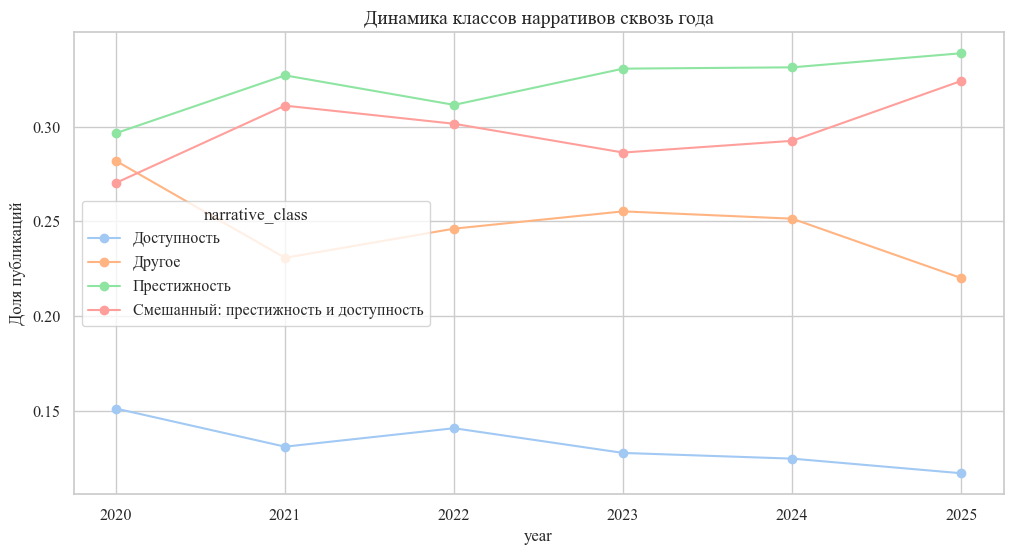

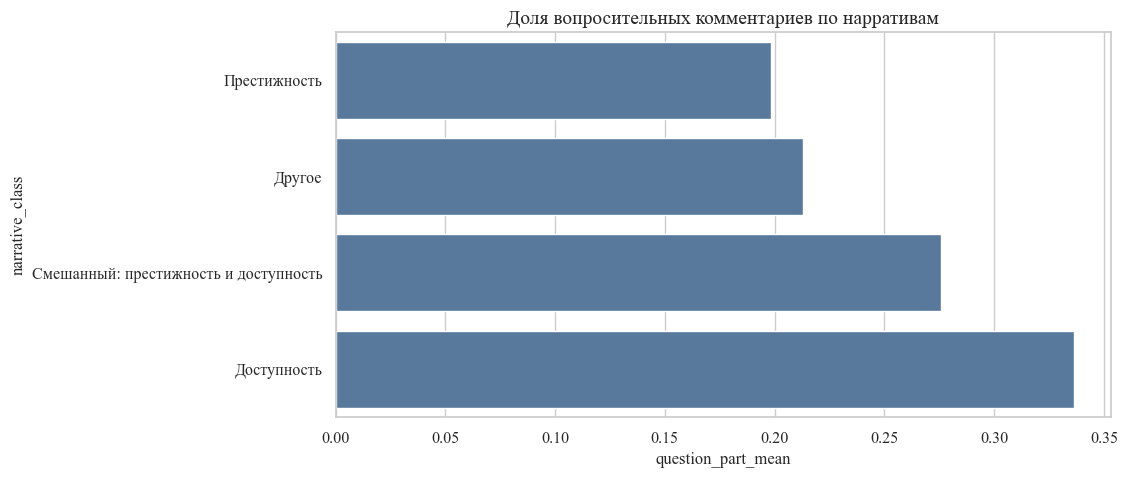

На графике с отражением динамики присутствия нарративов в публикациях заметно, что
посты с доступностью в течение шести лет имеется тренд на потерю долю в коммуникации университетов. При этом доля
престижности, наоборот, в общем тренде возрастает. Также примечательно, что в 2022 году у постов с доступностью был локальный максимум, а
у престижности – локальный минимум.

In [18]:
narrative_summary = posts.groupby('narrative_class').agg(n_posts=('post_id', 'size'),
                                                    views_median=('views', 'median'),
                                                    likes_rate_median=('likes_p1000_views', 'median'),
                                                    comments_rate_median=('comments_p1000_views', 'median'),
                                                    reposts_rate_median=('reposts_p1000_views', 'median'),
                                                    meaningful_comments_median=('meaningful_comm_clean', 'median'),
                                                    sentiment_mean=('sentiment_score', 'mean'),
                                                    prestige_density_mean=('prestige_density', 'mean'),
                                                    access_density_mean=('access_density', 'mean'),
                                                    contest_part=('contest_like_flag', 'mean'),
                                                    comment_question_part_mean=('comment_question_part', 'mean')).reset_index().sort_values('n_posts', ascending=0)
display(narrative_summary)
print('')

comment_summary = comms.groupby('narrative_class').agg(n_posts=('post_id', 'size'),
                                                    comments_count_median=('comments_count', 'median'),
                                                    contest_part=('contest_like_flag', 'mean'),
                                                    reposts_rate_median=('reposts_p1000_views', 'median'),
                                                    meaningful_comments_clean_median=('meaningful_comm_clean', 'median'),
                                                    meaningful_part_median=('comment_meaningful_part', 'median'),
                                                    question_part_mean=('comment_question_part', 'mean'),
                                                    duplicate_part_mean=('comment_duplicate_part', 'mean'),
                                                    short_part_mean=('comment_short_part', 'mean'),
                                                    sentiment_score_mean=('comment_sentiment_score', 'mean'),
                                                    caccess_barrier_mentions_mean=('comment_access_barrier_mentions', 'mean')).reset_index().sort_values('n_posts', ascending=0)
display(comment_summary)

display(Markdown(f'''Больше всего постов относится к престижности (112 тыс.), около 100 тыс. – к смешанному типу, 45 тыс. – к доступности.  
У престижности самые высокие медианные просмотры и довольно высокий лайк-рейт – престижные сюжеты получают
хорошую видимость и и позитивную реакцию. Самый высокий лайк-рейт у категории другое, скорее всего, туда попадают
поздравления6 культурные посты, студенческая жизнь и эмоциональные публикации.   
  
  Комментарии не являются популярными относительно лайков, но для социальных сетей это распространено.  
  По содержательным комментариям лидирует доступность. Причем публикации про доступность чаще
  вызывают вопросительные и содержательные комментарии. Это довольно логично, темы, связанные с поступлением, 
  общежитием, правилами приема и стоимостью обучения, важны для абитуриентов и требуют уточнения.  
  Доступность имеет самый высокий репост-рейт – важной информацией чаще делятся и пересылают другим. 
  Престижные посты больше окрашены позитивно (sentiment_mean 0,22) – победы, успехи, достижения – а доступность окрашена чуть менее позитивно (0,10). Доступность
  связана с более "серьезными" темами – документы, условия, барьеры, стоимость.  
  И наконец, среднее число упоминаний маркеров  доступности в комментариях – выше среди публикаций о доступности. 
  Больше содержательных комментариев вопросов, больше вовлеченность.  
  **На данном этапе видно, что престиж работает как имиджевая коммуникация, а доступность – как 
  коммуникация, требующая уточнений и обратной связи.** 
  '''))
year_narratives = posts.pivot_table(index='year', columns='narrative_class', values='post_id',
                                   aggfunc='count', fill_value=0).pipe(lambda x:x.div(x.sum(axis=1), axis=0)).reset_index()

year_narratives.set_index('year').plot(figsize=(12,6), marker='o')
plt.title('Динамика классов нарративов сквозь года')
plt.ylabel('Доля публикаций')
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=comment_summary, y='narrative_class', x='question_part_mean', color='#4C78A8')
plt.title('Доля вопросительных комментариев по нарративам')
plt.show()

display(Markdown(f'''На графике с отражением динамики присутствия нарративов в публикациях заметно, что
посты с доступностью в течение шести лет имеется тренд на потерю долю в коммуникации университетов. При этом доля
престижности, наоборот, в общем тренде возрастает. Также примечательно, что в 2022 году у постов с доступностью был локальный максимум, а
у престижности – локальный минимум.'''))

Проверка различий между нарративами  

Для того, чтобы сравнить нарративные классы, используется тест Манна-Уитни. Выбор пал именно на него потому что показатели вовлеченности в соцмедиа имеют ненормальное распределение, где большинство постов имеет мало комментариев, а меньшая их часть – очень много откликов.  
  Рассчитывается `p-value` и `rank_biserial` (размер эффекта). При большом корпусе даже мелкие различия становятся статистически значимыми, поэтому направление эффекта помогает строить более корректные интерпретации, помимо опоры только на значимость.

In [19]:
rows = []

metrics = ['likes_p1000_views',
          'reposts_p1000_views',
          'comments_p1000_views',
          'meaningful_comm_clean',
          'comment_question_part']
# определяем срезы для сравнения метрик
contrasts = {'prestige_vs_other': posts['narrative_class'].isin([
    'Престижность',
    'Смешанный: престижность и доступность']),
             'access_vs_other': posts['narrative_class'].isin([
    'Доступность',
    'Смешанный: престижность и доступность']),
             'mixed_vs_other': posts['narrative_class'].eq(
    'Смешанный: престижность и доступность')}

# цикл проводит статистические тесты по обозначенным срезам
for contrast, mask in contrasts.items():
    for metric in metrics:
        x = pd.to_numeric(posts.loc[mask, metric]).dropna()
        y = pd.to_numeric(posts.loc[~mask, metric]).dropna()

        if len(x) >=5 and len(y)>=5:
            u, p = stats.mannwhitneyu(x, y, alternative='two-sided')
            rank_biserial = 2 * u / (len(x) * len(y)) -1

            _, t_p = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        else:
            u, p, rank_biserial, t_p = np.nan, np.nan, np.nan, np.nan

        rows.append({'contrast':contrast,
                    'metric': metric,
                    'group_true_median': x.median() if len(x) else np.nan,
                    'group_false_median': y.median() if len(y) else np.nan,
                     'mannwhitneyu_p': p if np.isfinite(p) else np.nan,
                     'rank_biserial': rank_biserial if np.isfinite(rank_biserial) else np.nan,
                     'welch_t_p': t_p if np.isfinite(t_p) else np.nan
                    })

hypothesis_tests = pd.DataFrame(rows)

display(Markdown(f'''Из-за большого корпуса статистическая значимость присутствует почти во всех p-value.  
**Престижность vs другое.** Посты с нарративом престижности имеют более низкие показатели лайков, репостов, содержательных комментариев, чем остальные посты.
Такие посты скорее выступают скорее как способ вести имиджевую коммуникацию, чем вовлечь аудиторию.  
**Доступность vs другое.** Посты с нарративом доступности получают меньше лайков, но больше репостов и содержательных комментариев. Такие посты
работают лучше как способ распространения полезной информации, которую можно обсудить.  
**Смешанно vs другое.** Посты со смешанным нарративом тоже получают меньше лайков, чуть выше репостов. При этом такие посты
не дают прироста в содержательном отклике в комментариях.

'''))
display(hypothesis_tests)

Из-за большого корпуса статистическая значимость присутствует почти во всех p-value.  
**Престижность vs другое.** Посты с нарративом престижности имеют более низкие показатели лайков, репостов, содержательных комментариев, чем остальные посты.
Такие посты скорее выступают скорее как способ вести имиджевую коммуникацию, чем вовлечь аудиторию.  
**Доступность vs другое.** Посты с нарративом доступности получают меньше лайков, но больше репостов и содержательных комментариев. Такие посты
работают лучше как способ распространения полезной информации, которую можно обсудить.  
**Смешанно vs другое.** Посты со смешанным нарративом тоже получают меньше лайков, чуть выше репостов. При этом такие посты
не дают прироста в содержательном отклике в комментариях.



,contrast,metric,group_true_median,group_false_median,mannwhitneyu_p,rank_biserial,welch_t_p
0,prestige_vs_other,likes_p1000_views,9.14,10.35,0.00,-0.08,0.00
1,prestige_vs_other,reposts_p1000_views,1.07,1.15,0.00,-0.03,0.00
2,prestige_vs_other,comments_p1000_views,0.00,0.00,0.00,-0.06,0.09
3,prestige_vs_other,meaningful_comm_clean,1.00,2.00,0.00,-0.07,0.00
4,prestige_vs_other,comment_question_part,0.00,0.00,0.00,-0.03,0.00
5,access_vs_other,likes_p1000_views,8.10,10.78,0.00,-0.19,0.00
6,access_vs_other,reposts_p1000_views,1.17,1.04,0.00,0.05,0.00
7,access_vs_other,comments_p1000_views,0.00,0.00,0.00,-0.07,0.00
8,access_vs_other,meaningful_comm_clean,2.00,1.17,0.00,0.05,0.00
9,access_vs_other,comment_question_part,0.00,0.00,0.02,-0.00,0.00


### Тематическое моделирование LDA и контекст доступности высшего образования

LDA используется как дополнительный способ описать тематическую структуру корпуса. Словарная разметка отвечает на вопрос, присутствуют ли в тексте маркеры доступности и престижности; LDA же показывает более обширную тематику публикаций: науку, образовательные программы, студенческую жизнь, приемную кампанию, мероприяьтия, достижения и институциональную коммуникацию.  
  Названия тем присваиваются на основе наиболее весомых слов в каждой теме, то есть LDA используется как инструмент разведочного тематического анализа.

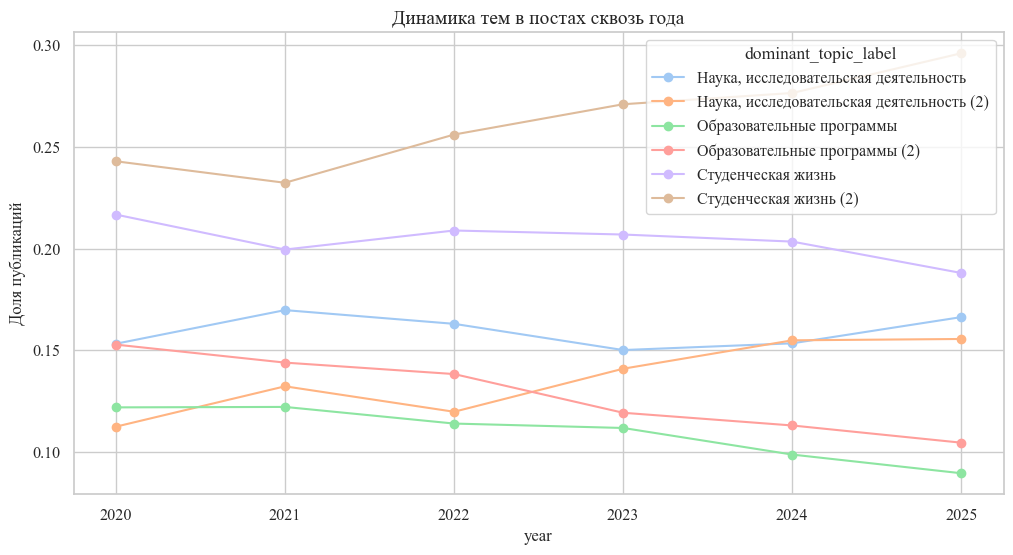

,topic_id,topic_label,top_words
0,0,"Наука, исследовательская деятельность","развития, технологий, научно, области, работы, технологии, конференции, которые, науки, научных, проектов, ученых, наука, системы, проекта"
1,1,"Наука, исследовательская деятельность (2)","академии, кафедры, имени, института, факультета, наук, гаугн, образования, ректор, совета, профессор, мид, директор, работе, доцент"
2,2,Студенческая жизнь,"мастер, имени, искусства, время, пройдет, театра, приглашаем, состоится, misis, выставка, класс, ждем, концерт, москва, октября"
3,3,Образовательные программы,"обучения, программы, образования, обучение, подготовки, программа, языка, образование, pushkin, образовательных, программ, вузов, inst, pushkin in..."
4,4,Образовательные программы (2),"конкурса, конкурс, открытых, дверей, открытых дверей, сайте, конкурсе, онлайн, прием, мифи, пройдет, подать, победителей, участников, заявку"
5,5,Студенческая жизнь (2),"место, сегодня, поздравляем, которые, жизни, очень, время, мгусит, желаем, победы, наши, спорта, наших, нашей, великой"


,dominant_topic_label,n_posts,likes_rate_median,comments_rate_median,reposts_rate_median,meaningful_comments_median,sentiment_mean,prestige_part,access_part,contest_part
5,Студенческая жизнь (2),92059,12.47,0.00,0.98,1.33,0.25,0.57,0.25,0.02
4,Студенческая жизнь,69967,10.23,0.00,1.39,2.00,0.13,0.43,0.39,0.01
0,"Наука, исследовательская деятельность",54865,7.11,0.00,0.95,1.00,0.17,0.79,0.45,0.01
1,"Наука, исследовательская деятельность (2)",47950,11.03,0.00,0.97,1.00,0.15,0.75,0.44,0.01
3,Образовательные программы (2),43139,7.08,0.00,1.26,2.00,0.17,0.61,0.67,0.02
2,Образовательные программы,37026,6.74,0.00,1.16,1.50,0.16,0.74,0.61,0.01


In [20]:
# отбираем посты c длиной текста > 40
topic_pool = posts.loc[posts['text_clean'].str.len()>40].copy()

vectoriser = CountVectorizer(max_features=5000,
                            min_df=15,
                            max_df=0.4,
                            ngram_range=(1,2),
                            stop_words=sorted(ru_stopwords),
                            token_pattern=r'(?u)\b[а-яa-z]{3,}\b')
X = vectoriser.fit_transform(topic_pool['text_clean'])

lda=LatentDirichletAllocation(n_components=6,
                             learning_method='online',
                             max_iter=8,
                             batch_size=2000,
                             evaluate_every=-1,
                             random_state=42,
                             n_jobs=1)

lda.fit(X)
feature_names = np.array(vectoriser.get_feature_names_out())

# набор регулярных выражений по шести темам
topic_re = {'Наука, исследовательская деятельность': r'науч|наук|исслед|лаборатор|технолог|эксперт|данн|публикац|инновац|разработ|открытие|экспедиц',
            'Карьера и партнерства': r'карьер|выпускник|работодат|компан|партнер|бизнес|стажир|стаж[её]р|професси|совместн|практик',
            'Инфраструктура и поддержка': r'общежит|кампус|сервис|поддержк|льгот|квот|стипенд|инклюз|психолог',
            'Студенческая жизнь': r'студенческ|фестивал|спорт|волонтер|концерт|клуб|команд|актив|кампус|меропри|экскурс',
            'Образовательные программы': r'программ|курс|обучен|сесси|экзамен|образован|лекц|школ|занят|практик',
            'Прием и поступление': r'кампани|программ|при[ёе]м|поступл|абитуриент|егэ|балл|зачисл|вступител|договор|бакалавр|специалит|магистр|дод|открытых дверей'}

rows = []
label_counts = Counter()

# цикл оценивает, ЧТО?
for topic_index, topic in enumerate(lda.components_):
    top_words = feature_names[np.argsort(topic)[::-1][:15]].tolist()
    topic_text = ' '.join(top_words)

    scores = {label: len(re.findall(pattern, topic_text))
    for label, pattern in topic_re.items()}

    label = max(scores, key=scores.get)
    if scores[label] == 0:
        label = 'Смешанная университетская повестка'
    label_counts[label] +=1
    if label_counts[label] >1:
        label = f'{label} ({label_counts[label]})'
    rows.append({'topic_id': topic_index,
                'topic_label': label,
                'top_words': ', '.join(top_words)})

topics = pd.DataFrame(rows)

X_all = vectoriser.transform(posts['text_clean'].fillna(''))
topic_probs = lda.transform(X_all)

# оцениваем вероятности принадлежности поста к теме и присваиваем наиболее вероятную тему
for i in range(topic_probs.shape[1]):
    posts[f'topic_{i}_prob'] =  topic_probs[:,i]

posts['dominant_topic_id'] = topic_probs.argmax(axis=1)
label_map = topics.set_index('topic_id')['topic_label'].to_dict()
posts['dominant_topic_label'] = posts['dominant_topic_id'].map(label_map)


topic_summary = posts.groupby('dominant_topic_label').agg(n_posts=('post_id', 'size'),
                                                    likes_rate_median=('likes_p1000_views', 'median'),
                                                    comments_rate_median=('comments_p1000_views', 'median'),
                                                    reposts_rate_median=('reposts_p1000_views', 'median'),
                                                    meaningful_comments_median=('meaningful_comm_clean', 'median'),
                                                    sentiment_mean=('sentiment_score', 'mean'),
                                                    prestige_part=('prestige_marker_count', lambda x: (x>0).mean()),
                                                    access_part=('access_marker_count', lambda x: (x>0).mean()),
                                                    contest_part=('contest_like_flag', 'mean')).reset_index().sort_values('n_posts', ascending=False)


year_topic = posts.pivot_table(index='year', columns='dominant_topic_label', values='post_id',
                                   aggfunc='count', fill_value=0).pipe(lambda x:x.div(x.sum(axis=1), axis=0)).reset_index()

year_topic.set_index('year').plot(figsize=(12,6), marker='o')
plt.title('Динамика тем в постах сквозь года')
plt.ylabel('Доля публикаций')
plt.show()

display(topics)
display(topic_summary)

Тема про спорт, достижения и поздравления имеет самый высокий лайк-рейт.  
Посты с темой с событиями и приглашениями чаще подвергается пересылке репостами и написанию комментариев.  
Посты с научной темой имеют высокую долю вхождений слов-маркеров престижа (0.79 и 0.75).  
Посты с темой образовательных программ и приемной кампании имеют высокую долю вхождений слов-маркеров доступности (0.61 и 0.67).  


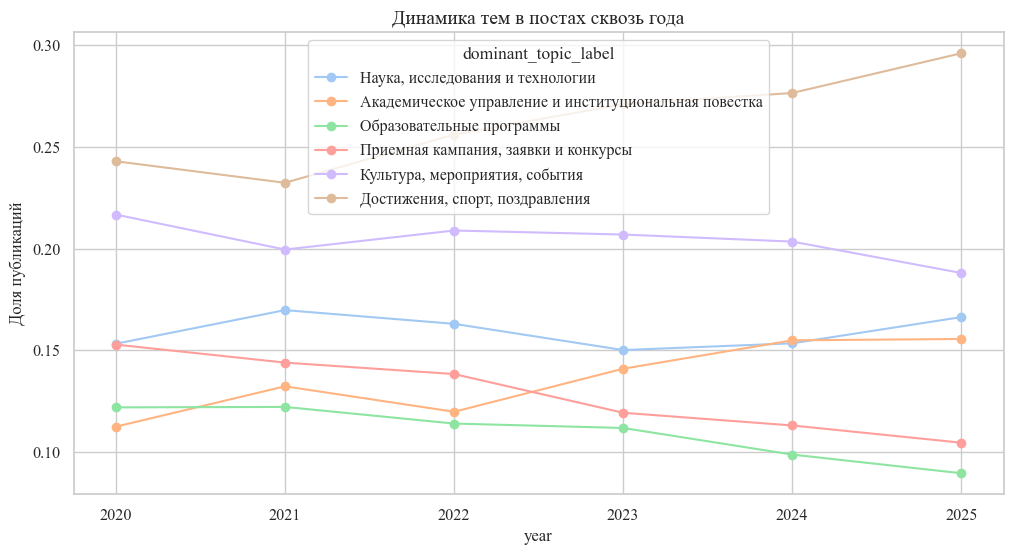

,topic_id,topic_label,top_words
0,0,"Наука, исследования и технологии","развития, технологий, научно, области, работы, технологии, конференции, которые, науки, научных, проектов, ученых, наука, системы, проекта"
1,1,Академическое управление и институциональная повестка,"академии, кафедры, имени, института, факультета, наук, гаугн, образования, ректор, совета, профессор, мид, директор, работе, доцент"
2,2,"Культура, мероприятия, события","мастер, имени, искусства, время, пройдет, театра, приглашаем, состоится, misis, выставка, класс, ждем, концерт, москва, октября"
3,3,Образовательные программы,"обучения, программы, образования, обучение, подготовки, программа, языка, образование, pushkin, образовательных, программ, вузов, inst, pushkin in..."
4,4,"Приемная кампания, заявки и конкурсы","конкурса, конкурс, открытых, дверей, открытых дверей, сайте, конкурсе, онлайн, прием, мифи, пройдет, подать, победителей, участников, заявку"
5,5,"Достижения, спорт, поздравления","место, сегодня, поздравляем, которые, жизни, очень, время, мгусит, желаем, победы, наши, спорта, наших, нашей, великой"


,dominant_topic_label,n_posts,likes_rate_median,comments_rate_median,reposts_rate_median,meaningful_comments_median,sentiment_mean,prestige_part,access_part,contest_part
5,"Достижения, спорт, поздравления",92059,12.47,0.00,0.98,1.33,0.25,0.57,0.25,0.02
4,"Культура, мероприятия, события",69967,10.23,0.00,1.39,2.00,0.13,0.43,0.39,0.01
0,"Наука, исследования и технологии",54865,7.11,0.00,0.95,1.00,0.17,0.79,0.45,0.01
1,Академическое управление и институциональная повестка,47950,11.03,0.00,0.97,1.00,0.15,0.75,0.44,0.01
3,"Приемная кампания, заявки и конкурсы",43139,7.08,0.00,1.26,2.00,0.17,0.61,0.67,0.02
2,Образовательные программы,37026,6.74,0.00,1.16,1.50,0.16,0.74,0.61,0.01


In [21]:
# переименуем темы в соответствии с содержанием
topic_label_ = {'Наука, исследовательская деятельность': 'Наука, исследования и технологии', 
               'Наука, исследовательская деятельность (2)': 'Академическое управление и институциональная повестка',
               'Студенческая жизнь': 'Культура, мероприятия, события',
               'Образовательные программы': 'Образовательные программы',
               'Образовательные программы (2)': 'Приемная кампания, заявки и конкурсы',
               'Студенческая жизнь (2)': 'Достижения, спорт, поздравления'}
topic_summary['dominant_topic_label'] = topic_summary['dominant_topic_label'].replace(topic_label_)

topics['topic_label'] = topics['topic_label'].replace(topic_label_)
year_topic = year_topic.rename(columns=topic_label_)

display(Markdown(f'''Тема про спорт, достижения и поздравления имеет самый высокий лайк-рейт.  
Посты с темой с событиями и приглашениями чаще подвергается пересылке репостами и написанию комментариев.  
Посты с научной темой имеют высокую долю вхождений слов-маркеров престижа (0.79 и 0.75).  
Посты с темой образовательных программ и приемной кампании имеют высокую долю вхождений слов-маркеров доступности (0.61 и 0.67).  
'''))
year_topic.set_index('year').plot(figsize=(12,6), marker='o')
plt.title('Динамика тем в постах сквозь года')
plt.ylabel('Доля публикаций')
plt.show()


display(topics)
display(topic_summary)

KWIC – key word in context – ключевое слово в тексте.  
Данный метод показывает фрагмент текста вокруг частотного термина, что позволяет проверить и интерпретировать словарь маркеров доступности. Например, "бюджетные места", "общежитие", "стипендия" могут встречаться абсолютно в разных контекстах. KWIC позволяет посмотреть контексты использования: в информационной коммуникации в рамках приемной кампании, в вопросах абитуриентов и родителей, в тексте претензий к условиям доступности образования.

In [22]:
# набор терминов, связанных с доступностью образования
access_terms = ['бюджетные места','платное обучение','стипендия','общежитие',
                'стоимость обучения','конкурсный набор', 'целевой набор', 
                'целевое обучение', 'льготы', 'квоты', 'образовательный грант', 
                'скидки на обучение', 'образовательный кредит', 'материальная помощь',
               'баллы ЕГЭ', 'гайд', 'навигатор', 'инклюзивная', 'доступная среда', 
               'адаптация', 'помощь студентам', 'онлайн-обучение', 'скидка', 'договор',
               'бесплатное обучение']

access_posts = posts.loc[posts['access_marker_count']>0, 'text_clean'].dropna()

access_vectoriser = CountVectorizer(max_features=100,
                            min_df=8,
                            ngram_range=(2,3),
                            stop_words=sorted(ru_stopwords),
                            token_pattern=r'(?u)\b[а-яa-z]{3,}\b')

X_access = access_vectoriser.fit_transform(access_posts)
counts = np.asarray(X_access.sum(axis=0)).ravel()

access_ngrams = pd.DataFrame({'ngram': access_vectoriser.get_feature_names_out(),
                             'count':counts})
access_ngrams = access_ngrams.sort_values('count', ascending=False).head(50)

kwic_rows = []
source = posts[['post_id', 'date', 'source_nickname', 'text']]

for term in access_terms:
    pattern = re.compile(term.replace('ЕГЭ', 'егэ'), flags=re.IGNORECASE)
    matches = source[source['text'].str.contains(pattern, regex=True, na=False)]

    for _, row in matches.head(10).iterrows():
        text = str(row['text'])
        m = pattern.search(text.lower())

        if not m:
            continue
        start = max(0, m.start()-120)
        end = min(len(text), m.end()+120)

        kwic_rows.append({'term':term,
                         'post_id':row['post_id'],
                         'date':row['date'],
                         'source_nickname':row['source_nickname'],
                         'context': re.sub(r'\s+', ' ', text[start:end]).strip()})
kwic_posts = pd.DataFrame(kwic_rows)

comment_kwic_rows = []
comment_source = comms[['post_id', 'date', 'source_nickname', 'comments']]

for term in access_terms:
    pattern = re.compile(term.replace('ЕГЭ', 'егэ'), flags=re.IGNORECASE)
    matches = comment_source[comment_source['comments'].str.contains(pattern, regex=True, na=False)]

    for _, row in matches.head(10).iterrows():
        comment_list =[part.strip() for part in re.split(r'\s+\|\s+', str(row['comments'])) if part.strip()][:100]

        for comment in comment_list:
            m = pattern.search(comment.lower())

            if m:
                start = max(0, m.start()-100)
                end = min(len(comment), m.end()+100)
        
                comment_kwic_rows.append({'term':term,
                                 'post_id':row['post_id'],
                                 'date':row['date'],
                                 'source_nickname':row['source_nickname'],
                                 'context': re.sub(r'\s+', ' ', comment[start:end]).strip()})
                break
kwic_comments = pd.DataFrame(comment_kwic_rows)

In [23]:
display(Markdown(f'''Самые частотные словосочетания среди постов с маркерами доступности:  
"открытых дверей", "прием заявок", "мастер-класс", "приемной комиссии", "подать заявку"  – показывает, что 
нарратив доступности в публикациях оформляется чаще через приемную кампанию и информационные сервисы. 
Присутствует также и институциональный шум, например "nust misis", "нияу мифи", "академии мид".  
Это скорее следы информационных источников, чем содержательные темы. Также присутствуют 
научно-административные сочетания, "доцент кафедры", "молодых ученых", "науки высшего". Часть доступности пересекается
с официальным административным языком и академической повесткой.'''))
display(access_ngrams.head(20))
display(Markdown(f'''Контекст, в котором встречаются ключевые термины:  
"бюджетные места" практически все из сообщества НИУ ВШЭ, связаны с зачислением. Это наглядный 
пример процедурной доступности – объясняют, где искать себя в списках, как и когда выйдет приказ и прочее.  
"платное обучение" часто встречается совместно с бесплатным. То есть этот термин цепляет более
широкий контекст финансовых условий обучения – платность/бесплатность, скидки, квоты.
'''))
display(kwic_posts.head(20))
display(Markdown(f'''Комментарии показывают не официальную коммуникацию вуза, а реакцию аудитории:  
*"иногородний студент из многодетной малообеспеченной семьи в общежитие уже 2й год попасть не может"    
"Обед 180 рублей - это хорошо, если стипендия сильно побольше, чем 1900 р.",  
"Подскажите пожалуйста, а как можно попасть в общежитие? Снимаем уже 7 месяцев 🤦‍♀️. Очень тяжело 😩",  
"не одарённые ребята со своими 80+ баллов по каждому предмету не вывозят конкурс. Для них только целевое обучение."*    
Под постами доступность превращается в практические вопросы и претензии: бюджетные места, стипендии,
стоимость, целевое обучение и прочее. 
'''))
display(kwic_comments.head(20))

Самые частотные словосочетания среди постов с маркерами доступности:  
"открытых дверей", "прием заявок", "мастер-класс", "приемной комиссии", "подать заявку"  – показывает, что 
нарратив доступности в публикациях оформляется чаще через приемную кампанию и информационные сервисы. 
Присутствует также и институциональный шум, например "nust misis", "нияу мифи", "академии мид".  
Это скорее следы информационных источников, чем содержательные темы. Также присутствуют 
научно-административные сочетания, "доцент кафедры", "молодых ученых", "науки высшего". Часть доступности пересекается
с официальным административным языком и академической повесткой.

,ngram,count
63,открытых дверей,13449
12,высшего образования,7213
1,nust misis,6550
73,прием заявок,5230
76,приемной комиссии,5184
41,мастер классы,5045
2,pushkin inst,4678
40,мастер класс,4487
24,доцент кафедры,4227
18,дипломатической академии,4080


Контекст, в котором встречаются ключевые термины:  
"бюджетные места" практически все из сообщества НИУ ВШЭ, связаны с зачислением. Это наглядный 
пример процедурной доступности – объясняют, где искать себя в списках, как и когда выйдет приказ и прочее.  
"платное обучение" часто встречается совместно с бесплатным. То есть этот термин цепляет более
широкий контекст финансовых условий обучения – платность/бесплатность, скидки, квоты.


,term,post_id,date,source_nickname,context
0,бюджетные места,76103,2025-08-25,hse.csv,👨‍🎓 Вышка открывает двери Новым магистрантам. Приемная комиссия опубликовала сведения о зачисленных на бюджетные места. Ищите себя в списке по инд...
1,бюджетные места,76038,2025-08-06,hse.csv,💙 Вышкинская семья продолжает расти Опубликованы сведения о зачисленных на бюджетные места программ бакалавриата/специалитета в основном этапе. Ищ...
2,бюджетные места,73258,2024-08-12,hse.csv,✨ Главное после выпуска из вуза — это найти себя (в списках зачисленных в магистратуру) Сведения о зачислении на бюджетные места уже доступны на с...
3,бюджетные места,73172,2024-07-25,hse.csv,"денты, поступившие в Вышку в прошлом году: vk.cc/cyG88n А в этом году прием документов уже завершен. Для зачисления на бюджетные места нужно предо..."
4,бюджетные места,72762,2024-05-20,hse.csv,"жность для абитуриентов, которые оказались в сложных жизненных ситуациях и не могут на равных конкурировать в борьбе за бюджетные места и оплачива..."
5,бюджетные места,69176,2023-08-30,hse.csv,В этом году по отдельной квоте на бюджетные места в Высшую школу экономики поступило свыше 150 абитуриентов. Об этом ректор НИУ ВШЭ Никита Анисимо...
6,бюджетные места,69075,2023-08-11,hse.csv,"Приемная комиссия НИУ ВШЭ опубликовала сведения о зачислении абитуриентов, поступивших на бюджетные места магистратуры: vk.cc/cq7EsM Абитуриенты и..."
7,бюджетные места,69039,2023-08-08,hse.csv,"Приемная комиссия опубликовала списки абитуриентов, приглашенных к зачислению на бюджетные места в магистратуру НИУ ВШЭ. Чтобы попасть в приказ о ..."
8,бюджетные места,69028,2023-08-06,hse.csv,"Приемная комиссия НИУ ВШЭ опубликовала сведения о зачислении абитуриентов, поступающих по основному конкурсу, на бюджетные места бакалавриата и сп..."
9,бюджетные места,69021,2023-08-04,hse.csv,Уже 8 августа будут опубликованы конкурсные списки поступающих на бюджетные места в магистратуру НИУ ВШЭ и объявлены критерии для заключения догов...


Комментарии показывают не официальную коммуникацию вуза, а реакцию аудитории:  
*"иногородний студент из многодетной малообеспеченной семьи в общежитие уже 2й год попасть не может"    
"Обед 180 рублей - это хорошо, если стипендия сильно побольше, чем 1900 р.",  
"Подскажите пожалуйста, а как можно попасть в общежитие? Снимаем уже 7 месяцев 🤦‍♀️. Очень тяжело 😩",  
"не одарённые ребята со своими 80+ баллов по каждому предмету не вывозят конкурс. Для них только целевое обучение."*    
Под постами доступность превращается в практические вопросы и претензии: бюджетные места, стипендии,
стоимость, целевое обучение и прочее. 


,term,post_id,date,source_nickname,context
0,бюджетные места,73794,2024-10-31,hse.csv,"Интересно было бы также увидеть аналогичный пост про динамику статистики приёма на бюджетные места ребят из российской глубинки, коренного населен..."
1,бюджетные места,69039,2023-08-08,hse.csv,"Добрый день! А где можно ознакомиться со списком абитуриентов, приглашённых к зачислению на бюджетные места по направлению ""Комплаенс и оценка пра..."
2,бюджетные места,66127,2022-10-03,hse.csv,"«Часть студентов Высшей школы экономики решили сбежать из России, сохранив за собой бюджетные места. Для этих целей некоторые из них даже предложи..."
3,бюджетные места,62454,2021-08-05,hse.csv,ёной волне» на Политологии при 60 бюджетных мест. Плюс нет ещё списка БВИ и особой квоты. Расширили бюджетные места?
4,бюджетные места,62208,2021-07-16,hse.csv,"ни находятся в сложной жизненной ситуации и направление, на которое они поступают, не подразумевает бюджетные места?"
5,бюджетные места,64919,2025-07-31,mgu.csv,"подать в МГУ, она сказала, если я попаду, то будет мной очень гордиться, я ее послушала, потому что бюджетные места на мою специальность были толь..."
6,бюджетные места,50277,2024-03-14,mfti.csv,А почему тогда бюджетные места сокращаются? Если прибыль увеличивается? Воруют?!
7,бюджетные места,421578,2025-03-27,mirea.csv,"Перевод на бюджетные места — это не только финансовая поддержка, но и признание академических достижений студентов, что особен"
8,бюджетные места,407367,2025-01-29,mirea.csv,Отличная новость! Поздравляю с переводом на бюджетные места 🫶
9,бюджетные места,20142,2020-10-29,mirea.csv,"Кроме этого, РТУ МИРЭА стал 4-м вузом по качеству приёма (среднему баллу ЕГЭ зачисленных на бюджетные места) . По данному показателю обошёл такие ..."


В официальных постах нарратив доступности представляется чаще как информационно-процедурная повестка: приемная комиссия, дни открытых дверей, бюджетные места. В комментариях же та же тема приобретает более проблемный характер. Пользователи задают (неудобные) вопросы о стоимости обучения, доступности общежития для иногородних, размере стипендий, условиях целевого набора, а также высказывают претензии по тем же вопросам. Таким образом, комментарии позволяют увидеть не только заявляемую доступность образования, но и барьеры его доступности, называемые аудиторией – родителями, студентами и абитуриентами.

## Baseline-модели и метрики

Этот блок дополняет нарративный анализ. Его задача – проверить, помогают ли текстовые признаки, нарративные классы, темы и метаданные постов диагностически различать публикации по уровню содержательного отклика.

  Целевая переменная в данном случае – это высокий содержательный отклик в комментариях. Пост относится к положительному классу, если `meaningful_comm_clean` выше 75% перцентиля. Так мы не просто анализирует средние различия между нарративами, а заодно и проверяем, можно ли по признакам выделить те, посты, которые вызовут содержательный отклик аудитории с большей вероятностью. 

   Нарративы рассматриваются не только как способ репрезентации высшего образования, но и как формы коммуникации, которые по-разному связаны с обратной связью от подписчиков.

In [24]:
topic_cols = [col for col in posts.columns if col.startswith('topic_') and col.endswith('_prob')]

emoji_col = 'emodji_count' if 'emodji_count' in posts.columns else 'emoji_count'

num_features = ['year', 'month', 'text_len', 'token_count', emoji_col, 'exclamation_count',
                    'question_count', 'has_url', 'caps_part', 'prestige_density', 'access_density',
                    'financial_access_density', 'procedural_access_density', 'informational_access_density',
                    'infrastructure_support_density', 'sentiment_score', 'log_views'] + topic_cols

cat_features = ['source_nickname', 'narrative_class', 'sentiment_label', 'dominant_topic_label', 'season']

cols_for_da = ['text_clean', 'meaningful_comm_clean', 'contest_like_flag', 'views'] + num_features + cat_features

ml = posts.loc[posts['meaningful_comm_clean'].notna() &posts['contest_like_flag'].fillna(0).eq(0) & posts['views'].gt(0),
    list(dict.fromkeys(cols_for_da))].copy()

threshold = float(ml['meaningful_comm_clean'].quantile(0.75))
if  threshold< 1:
    threshold = 1.0

ml['high_content_comment_response'] = (ml['meaningful_comm_clean']> threshold).astype(int)

X = ml[['text_clean'] + num_features + cat_features]
y = ml['high_content_comment_response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler(with_mean=False))])

cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))])
text_tfidf = TfidfVectorizer(max_features=4000, 
                            min_df=3,
                            max_df=0.85, 
                            ngram_range=(1,2),
                            stop_words=sorted(ru_stopwords),
                            token_pattern=r'(?u)\b[а-яa-z]{3,}\b',
                            sublinear_tf=True)

text_plus_features = ColumnTransformer(transformers=[('text', text_tfidf, 'text_clean'),
                                                    ('num', num_pipe, num_features),
                                                    ('cat', cat_pipe, cat_features)], sparse_threshold=0.3)

only_features = ColumnTransformer(transformers=[('num', num_pipe, num_features),
                                                ('cat', cat_pipe, cat_features)], sparse_threshold=0.3)

models = {'Dummy most frequent': Pipeline([('prep', only_features),
                                          ('model', DummyClassifier(strategy='most_frequent'))]),
         'Logistic regression + TF-IDF': Pipeline([('prep', text_plus_features),
                                                   ('model', LogisticRegression(max_iter=1200,
                                                                               class_weight='balanced',
                                                                               solver='liblinear',
                                                                               random_state=42))]),
          'LinearSVC + TF-IDF': Pipeline([('prep', text_plus_features),
                                          ('model', LinearSVC(class_weight='balanced', random_state=42))]),
          'Decision tree': Pipeline([('prep', only_features),
                                          ('model', DecisionTreeClassifier(max_depth=8,
                                                                           min_samples_leaf=80,
                                                                           random_state=42))]),        
          'RandomForest': Pipeline([('prep', only_features),
                                          ('model', RandomForestClassifier(n_estimators=80,
                                                                           max_depth=12,
                                                                           min_samples_leaf=25,
                                                                           class_weight='balanced_subsample',
                                                                           n_jobs=1,
                                                                           random_state=42))]),        
          'KNN': Pipeline([('prep', only_features),
                           ('model', KNeighborsClassifier(n_neighbors=25, weights='distance'))])}        

rows = []
fit_models = {}

progress_bar = tqdm(models.items(), total=len(models), desc='Обучение baseline-моделей')
for name, model in progress_bar:
    progress_bar.set_postfix_str(name)

    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    row = {'model': name,
          'train_accuracy': accuracy_score(y_train, pred_train),
          'test_accuracy': accuracy_score(y_test, pred_test), 
           'train_balanced_accuracy': balanced_accuracy_score(y_train, pred_train),
          'test_balanced_accuracy': balanced_accuracy_score(y_test, pred_test),
           'train_F1': f1_score(y_train, pred_train, zero_division=0),
           'test_F1': f1_score(y_test, pred_test, zero_division=0),
           'test_precision': precision_score(y_test, pred_test, zero_division=0),
           'test_recall': recall_score(y_test, pred_test, zero_division=0)}
           
    if hasattr(model, 'predict_proba'):
        score_train = model.predict_proba(X_train)[:,1]
        score_test = model.predict_proba(X_test)[:,1]

        row['train_roc_auc'] = roc_auc_score(y_train, score_train)
        row['test_roc_auc'] = roc_auc_score(y_test, score_test)
        row['test_pr_auc'] = average_precision_score(y_test, score_test)

    elif hasattr(model, 'decision_function'):
        score_train = model.decision_function(X_train)
        score_test = model.decision_function(X_test)

        row['train_roc_auc'] = roc_auc_score(y_train, score_train)
        row['test_roc_auc'] = roc_auc_score(y_test, score_test)
        row['test_pr_auc'] = average_precision_score(y_test, score_test)
    else:
        row['train_roc_auc'] = np.nan
        row['test_roc_auc'] = np.nan
        row['test_pr_auc'] = np.nan

    row['overfit_F1_gap'] = row['train_F1'] - row['test_F1']
    rows.append(row)
    fit_models[name] = model

Обучение baseline-моделей: 100%|█████████████| 6/6 [05:13<00:00, 52.31s/it, KNN]


In [25]:
classification_metrics = pd.DataFrame(rows).sort_values('test_F1', ascending=False)

best_name = classification_metrics.iloc[0]['model']
best_model = fit_models[best_name]

report = classification_report(y_test, best_model.predict(X_test), zero_division=0)

In [26]:
display(Markdown(f'''Классификационный базлайн разделяет публикации на группы с высоким и невысоким содержательным откликом.
(meaningful_comm_clean > 3.6)  
Сравнивался наивный Dummy most frequent базлайн и более продвинутые модели.
Положительный класс составляет около 25%, поэтому очень важно аккуратно смотреть на аccuracy. 
У Dummy он всегда показывает "нет высокого отклика". Выраженной диагностической способности у Dummy нет.  

  Лучшая модель – Logistic regression + TF-IDF.  
  Она находит 65% публикаций с высоким откликом, однако precision 0,44 – часть классификаций относится к ложноположительным.   

    LinearSVC + TF-IDF имеет близкие метрики, что подтверждает пользу от TF-IDF текстовых признаков.   

      RandomForest тоже имеет похожие значения метрик, но работает при этом без текстового TF-IDF, а на
      инженерных признаках и категориях. Нарративы, тема, источник, длина текста, тональность и вовлеченность тоже 
      сигнализируют классы.  

      Decision tree имеет высокую аccuracy, но слабый recall – дерево слишком осторожно относит публикации к классу высокого откликаmmy median почти 
      всем объектам присваивает типичное значение медианы, но большую часть постов с высоким откликом все-таки пропускает.

      У KNN наблюдается переобучение. Он запомнил тренировочную выборку и имеет плохую обобщаюшую способность.  

        Таким образом, модели превосходят наивный базлайн. Большую устойчивость покзаали модели с TF-IDF, лексическое содержание
        публикации важно. При этом случайны лес показывает сопоставимое качество без текстовых признаков.

'''))
display(classification_metrics)
print(report)

Классификационный базлайн предсказывает, будет ли у поста высокий содержательный
комментарийный отклик. (meaningful_comm_clean > 3.6)  
Сравнивался наивный Dummy most frequent базлайн и более продвинутые модели.
Положительный класс составляет около 25%, поэтому очень важно аккуратно смотреть на аccuracy. 
У Dummy он всегда показывает "нет высокого отклика". Реальной предсказательной силы нет.  

  Лучшая модель – Logistic regression + TF-IDF.  
  Она находит 65% публикаций с высоким откликом, однако precision 0,44 – часть предсказаний ложноположительны.   

    LinearSVC + TF-IDF имеет близкие метрики, что подтверждает пользу от TF-IDF текстовых признаков.   

      RandomForest тоже имеет похожие значения метрик, но работает при этом без текстового TF-IDF, а на
      инженерных признаках и категориях. Нарративы, тема, источник, длина текста, тональность и вовлеченность тоже 
      сигнализируют классы.  

      Decision tree имеет высокую аccuracy, но слабый recall – дерево слишком осторожно предсказывает высокий отклик. 
      Оно часто предсказывает верно, но большую часть постов с высоким откликом все-таки пропускает.

      У KNN наблюдается переобучение. Он запомнил тренировочную выборку и имеет плохую обобщаюшую способность.  

        Таким образом, модели превосходят наивный базлайн. Большую устойчивость покзаали модели с TF-IDF, лексическое содержание
        публикации важно. При этом случайны лес показывает сопоставимое качество без текстовых признаков.



,model,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_F1,test_F1,test_precision,test_recall,train_roc_auc,test_roc_auc,test_pr_auc,overfit_F1_gap
1,Logistic regression + TF-IDF,0.74,0.70,0.73,0.68,0.58,0.52,0.44,0.65,0.81,0.75,0.54,0.06
2,LinearSVC + TF-IDF,0.74,0.70,0.74,0.68,0.59,0.51,0.43,0.64,0.82,0.74,0.52,0.08
4,RandomForest,0.74,0.71,0.70,0.67,0.55,0.51,0.45,0.59,0.79,0.75,0.55,0.04
3,Decision tree,0.79,0.79,0.62,0.61,0.39,0.37,0.69,0.25,0.75,0.73,0.53,0.02
5,KNN,1.00,0.77,1.00,0.58,1.00,0.29,0.65,0.19,1.00,0.71,0.49,0.71
0,Dummy most frequent,0.75,0.75,0.50,0.50,0.00,0.00,0.00,0.00,0.50,0.50,0.25,0.00


              precision    recall  f1-score   support

           0       0.86      0.72      0.78     17679
           1       0.44      0.65      0.52      5887

    accuracy                           0.70     23566
   macro avg       0.65      0.68      0.65     23566
weighted avg       0.75      0.70      0.72     23566



Коэффициенты лог-регрессии помогают определить, какие признаки связаны с вероятностью того, будет ли у поста
высокий отклик содержательными комментариями.  
Положительный коэффициент – наличие признака повышает вероятность того, что на пост будет высокий отклик содержательными комментариями.  
Отрицательный – снижает эту вероятность.  

In [27]:
coef_table = pd.DataFrame()

logit = fit_models['Logistic regression + TF-IDF']
feature_names = logit.named_steps['prep'].get_feature_names_out()
coefs = logit.named_steps['model'].coef_[0]

coef_table = pd.DataFrame({'feature': feature_names, 'coef': coefs})

coef_table['abs_coef'] = coef_table['coef'].abs()

logistic_coeffs = pd.concat([coef_table.sort_values('coef', ascending=False).head(35).assign(direction='positive'),
                            coef_table.sort_values('coef', ascending=True).head(35).assign(direction='negative')])

display(Markdown(f'''
Сильными положительными признаками являются "text__свои вопросы", "text__списки", "text__комментариях", "text__расскажите", "text__общежитий".  
Посты приглашают аудиторию задавать вопросы и писать комментарии или связаны с зачислением, обежитием и чаще получают содержательные отклики.  
Также есть признаки-источники (сообщества вузов) или признаки-бренды "text__гитра", "text__бауманка", "cat__source_nickname_mirea.csv". Похоже, что
для отдельных сообществ в данных выше вероятность содержательного отклика как такового. Возможно, это из-за стиля ведения коммуникации сообщества.  
  
Сильными негативными признаками являются "text__спортсмены", "text__министерства", "text__университетов".  
Похоже, что это посты-маркеры более официальной коммуникации, где аудитория меньше вовлекается в содержательный разговор.'''))
display(logistic_coeffs)


Сильными положительными признаками являются "text__свои вопросы", "text__списки", "text__комментариях", "text__расскажите", "text__общежитий".  
Посты приглашают аудиторию задавать вопросы и писать комментарии или связаны с зачислением, обежитием и чаще получают содержательные отклики.  
Также есть признаки-источники (сообщества вузов) или признаки-бренды "text__гитра", "text__бауманка", "cat__source_nickname_mirea.csv". Похоже, что
для отдельных сообществ в данных выше вероятность содержательного отклика как такового. Возможно, это из-за стиля ведения коммуникации сообщества.  
  
Сильными негативными признаками являются "text__спортсмены", "text__министерства", "text__университетов".  
Похоже, что это посты-маркеры более официальной коммуникации, где аудитория меньше вовлекается в содержательный разговор.

,feature,coef,abs_coef,direction
57,text__volunteer,2.62,2.62,positive
4065,cat__source_nickname_mirea.csv,2.57,2.57,positive
58,text__volunteer rtumirea,2.50,2.50,positive
16,text__gubkinuniversity gubkin,2.49,2.49,positive
2864,text__ргуимкосыгина университеткосыгина,2.32,2.32,positive
2,text__bmstu бауманка,2.25,2.25,positive
1907,text__новости nust,2.24,2.24,positive
3050,text__свои вопросы,2.12,2.12,positive
2762,text__прямой,2.07,2.07,positive
3305,text__списки,1.96,1.96,positive


In [28]:
reg = ml.copy()
y_reg = np.log1p(reg['meaningful_comm_clean'].clip(lower=0))
X_reg = reg[['text_clean'] + num_features +cat_features]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg,
                                                                   test_size=0.25,
                                                                   random_state=42)

reg_models = {'Dummy median': Pipeline([('prep', only_features),
                                       ('model', DummyRegressor(strategy='median'))]),
             'Ridge + TF-IDF': Pipeline([('prep', text_plus_features),
                                       ('model', Ridge(alpha=2,random_state=42))])}

reg_rows = []


progress_bar_reg = tqdm(reg_models.items(), total=len(reg_models), desc='Обучение baseline-моделей LR')
for name, model in progress_bar_reg:
    progress_bar_reg.set_postfix_str(name)

    model.fit(X_train_reg, y_train_reg)
    pred_train = model.predict(X_train_reg)
    pred_test = model.predict(X_test_reg)

    reg_rows.append({'model': name,
          'train_mae': mean_absolute_error(y_train_reg, pred_train),
          'test_mae': mean_absolute_error(y_test_reg, pred_test), 
           'train_rmse': np.sqrt(mean_squared_error(y_train_reg, pred_train)),
          'test_rmse': np.sqrt(mean_squared_error(y_test_reg, pred_test)),
           'train_R2': r2_score(y_train_reg, pred_train),
           'test_R2': r2_score(y_test_reg, pred_test),
           'overfit_rmse_gap': (np.sqrt(mean_squared_error(y_test_reg, pred_test)) - np.sqrt(mean_squared_error(y_train_reg, pred_train)))}
)
reg_metrics = pd.DataFrame(reg_rows).sort_values('test_rmse')

ml_baseline = {'ml_rows': str(len(ml)),
              'target_threshold': f'{threshold:.3f}',
              'positive_rate': f'{ml["high_content_comment_response"].mean():.3f}', 
              'best_classifier': str(best_name)}

Обучение baseline-моделей LR: 100%|█| 2/2 [00:15<00:00,  7.59s/it, Ridge + TF-ID


In [29]:
display(Markdown(f'''Регрессионный базлайн показывает, что модель с текстом и признаками лучше наивной модели.  
Dummy median почти всем предсказывает типичное значение медианы. R2 на тестовой выборке вообще отрицательный.  

Ridge + TF-IDF показала себя лучше. Текстовые признаки, нарративы, темы и остальные метаданные объясняют
около 25% вариации лог-числа содержательных комментариев.
'''))
display(reg_metrics)

display(Markdown(f'''В блок вошли 94 тыс постов: строки с ненулевой валидной оценкой содержательных
комментариев, те БЕЗ конкурнсых/механических случаев и с ненулевыми просмотрами.  
Пост считается тем постом, на который "высоко откликнутся пользователи" если имеет порог 
meaningful_comm_clean > 3.6. Таких постов 25% (positive_rate) тк порог взят по 75% перцентилю.'''))
display(pd.DataFrame([ml_baseline]))

Регрессионный базлайн показывает, что модель с текстом и признаками лучше наивной модели.  
Dummy median почти всем предсказывает типичное значение медианы. R2 на тестовой выборке вообще отрицательный.  

Ridge + TF-IDF показала себя лучше. Текстовые признаки, нарративы, темы и остальные метаданные объясняют
около 25% вариации лог-числа содержательных комментариев.


,model,train_mae,test_mae,train_rmse,test_rmse,train_R2,test_R2,overfit_rmse_gap
1,Ridge + TF-IDF,0.58,0.60,0.74,0.77,0.31,0.25,0.03
0,Dummy median,0.68,0.69,0.91,0.91,-0.05,-0.05,0.01


В блок вошли 94 тыс постов: строки с ненулевой валидной оценкой содержательных
комментариев, те БЕЗ конкурнсых/механических случаев и с ненулевыми просмотрами.  
Пост считается тем постом, на который "высоко откликнутся пользователи" если имеет порог 
meaningful_comm_clean > 3.6. Таких постов 25% (positive_rate) тк порог взят по 75% перцентилю.

,ml_rows,target_threshold,positive_rate,best_classifier
0,94262,3.600,0.250,Logistic regression + TF-IDF


## Выводы этапа  
  1. В корпусе публикации сообществ вузов более явно заметен нарратив престижности. Он связывается с достижениями, попаданием в рейтинги, научной активностью, экспертностью, карьерными прорывами и в целом – позитивной репрезентаций университета.
  2. Нарратив доступности часто присутствует в смешанных публикациях вместе с престижностью, как самостоятельный класс встречается реже. Он связан с бюджетными местами, приемной кампанией, поступлением, квотами, льготами, стипендиями, стоимостью обучения, общежитием и информационной поддержкой о ходе приема.
  3. Престижные публикации чаще выполняют именно имиджевую функцию репрезентации вуза в медиапространстве. Они позитивно окрашены, хорошо вписываются в репутационное позиционирование университетов, но при этом не всегда дает более высокий содержательный отклик аудитории.
  4. Публикации о доступности меньше свойственны набирать больше число лайков, но больше ориентирвоаны на репосты, вопросы и содержательные комментарии. Доступность в данном ключе интерпретируется как связанная с практико-ориентированным информационным нарративом, который активнее вызывает реакцию у аудитории.
  5. Комментарии к публикациям отражают некоторые различия между тем, какую коммуникацию простраивает университет и тем, как аудитория воспринимает такой контент. Доступность в постах оформляется как информационно-процедурная, часто представляется как пространство для обсуждения существующих барьеров – стоимости обучения, числом бюджетных и квотных мест, общежитий, стипендий.
  6. Тематическое моделирование LDA показало, что корпус описывается несколькими тематическими повестками – наука и технологии, институциональная коммуникаци, культурные и публичные события, приемная кампания, образовательные программы, достижения и поздравления.
  7. Baseline-модели демонстрируют, что признаки (как текстовые, так и метаданные) демонстрируют связь с высоким содержательным откликом в комментариях. Лучшей моделью классификации является логическая регрессия с TF-IDF.
  8. Промежуточные результаты усиливают тезис о том, что содержательный отклик аудитории связан не только с ее вовлеченностью, но и с моделью коммуникации, простраиваемой вузом, темой публикации и нарративной рамкой, задающей обсуждение.
  9. Важно учитывать, что нарративные классы построены на основе авто операционализации в виде словаря. Ручная валидация части корпуса показала, что авто разметка имеет ограничения и может переобнаруживать маркеры нарративов, чаще там, где ручная разметка относит пост к классу "другое". Таким образом, результаты данного этапа интерпретируются как различия между эвристически выделенными классами, а не как экспертная классификация публикаций